In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [5]:
FILE = 'Nassau Candy Distributor (1).csv'

df = pd.read_csv(FILE)
print(f'✅ Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')


✅ Dataset loaded: 10,194 rows, 18 columns
Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

df['Lead Time'] = (df['Ship Date'] - df['Order Date']).dt.days

print('✅ Dates parsed & Lead Time calculated!')
print(f'\nLead Time stats:')
print(f'  Min  : {df["Lead Time"].min()} days')
print(f'  Max  : {df["Lead Time"].max()} days')
print(f'  Mean : {df["Lead Time"].mean():.1f} days')
display(df[['Order Date','Ship Date','Lead Time']].head(5))

✅ Dates parsed & Lead Time calculated!

Lead Time stats:
  Min  : 904 days
  Max  : 1642 days
  Mean : 1320.8 days


,Order Date,Ship Date,Lead Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [7]:
product_factory = {
    "Wonka Bar - Nutty Crunch Surprise"   : "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows"           : "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious"      : "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate"          : "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel"   : "Wicked Choccy's",
    "Laffy Taffy"                         : "Sugar Shack",
    "SweeTARTS"                           : "Sugar Shack",
    "Nerds"                               : "Sugar Shack",
    "Fun Dip"                             : "Sugar Shack",
    "Fizzy Lifting Drinks"                : "Sugar Shack",
    "Everlasting Gobstopper"              : "Secret Factory",
    "Hair Toffee"                         : "The Other Factory",
    "Lickable Wallpaper"                  : "Secret Factory",
    "Wonka Gum"                           : "Secret Factory",
    "Kazookles"                           : "The Other Factory"
}

df['Factory'] = df['Product Name'].map(product_factory)

print('✅ Products mapped to Factories!')
print('\nFactory distribution:')
print(df['Factory'].value_counts())

✅ Products mapped to Factories!

Factory distribution:
Factory
Lot's O' Nuts        5692
Wicked Choccy's      4152
Secret Factory        217
The Other Factory     100
Sugar Shack            33
Name: count, dtype: int64


In [8]:
factory_coords = {
    "Lot's O' Nuts"    : (32.881893, -111.768036),
    "Wicked Choccy's"  : (32.076176,  -81.088371),
    "Sugar Shack"      : (48.119140,  -96.181150),
    "Secret Factory"   : (41.446333,  -90.565487),
    "The Other Factory": (35.117500,  -89.971107)
}

region_coords = {
    "Interior" : (39.500000, -98.350000),
    "Atlantic"  : (35.000000, -78.000000),
    "Gulf"      : (29.760000, -95.370000),
    "Pacific"   : (34.050000, -118.240000)
}

print('✅ Coordinates defined!')
print('\nFactory locations:')
for f, (lat, lon) in factory_coords.items():
    print(f'  {f}: ({lat}, {lon})')
    

✅ Coordinates defined!

Factory locations:
  Lot's O' Nuts: (32.881893, -111.768036)
  Wicked Choccy's: (32.076176, -81.088371)
  Sugar Shack: (48.11914, -96.18115)
  Secret Factory: (41.446333, -90.565487)
  The Other Factory: (35.1175, -89.971107)


In [9]:
def haversine(lat1, lon1, lat2, lon2):
    R = 3958.8  # Earth radius in miles
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def get_distance(row):
    factory = row['Factory']
    region  = row['Region']
    if factory in factory_coords and region in region_coords:
        f_lat, f_lon = factory_coords[factory]
        r_lat, r_lon = region_coords[region]
        return round(haversine(f_lat, f_lon, r_lat, r_lon), 2)
    return None

df['Shipping Distance (miles)'] = df.apply(get_distance, axis=1)

print('✅ Shipping distances calculated!')
print('\nAverage distance by Factory:')
print(df.groupby('Factory')['Shipping Distance (miles)'].mean().round(1).sort_values())

✅ Shipping distances calculated!

Average distance by Factory:
Factory
The Other Factory     923.4
Secret Factory        965.2
Lot's O' Nuts        1044.6
Sugar Shack          1145.4
Wicked Choccy's      1157.9
Name: Shipping Distance (miles), dtype: float64


In [10]:
print('✅ Phase 1 Complete — Master Dataset Ready!')
print(f'\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\nNew columns added:')
print(f'  Lead Time              : {df["Lead Time"].dtype}')
print(f'  Factory                : {df["Factory"].dtype}')
print(f'  Shipping Distance      : {df["Shipping Distance (miles)"].dtype}')
print(f'\nLead Time range: {df["Lead Time"].min()} to {df["Lead Time"].max()} days')
print(f'Distance range : {df["Shipping Distance (miles)"].min()} to {df["Shipping Distance (miles)"].max()} miles')

display(df[['Product Name','Factory','Region','Ship Mode',
            'Lead Time','Shipping Distance (miles)','Sales','Gross Profit']].head(10))


✅ Phase 1 Complete — Master Dataset Ready!

Shape: 10,194 rows × 21 columns

New columns added:
  Lead Time              : int64
  Factory                : str
  Shipping Distance      : float64

Lead Time range: 904 to 1642 days
Distance range : 269.13 to 2143.85 miles


,Product Name,Factory,Region,Ship Mode,Lead Time,Shipping Distance (miles),Sales,Gross Profit
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,909,1092.40,6.50,4.22
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Standard Class,909,1092.40,7.50,4.90
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,Standard Class,909,875.45,10.47,7.47
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,Standard Class,909,875.45,10.80,7.50
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,912,269.13,11.25,7.35
5,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Gulf,Standard Class,909,990.51,32.40,22.50
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Gulf,Standard Class,909,860.86,7.50,4.90
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,Gulf,First Class,906,860.86,9.75,6.33
8,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Gulf,Standard Class,909,990.51,6.98,4.98
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,Gulf,Standard Class,909,860.86,13.00,8.44


C:\Users\khush\AppData\Local\Temp\ipykernel_18940\2567114106.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Ship Mode', y='Lead Time', palette='Blues')


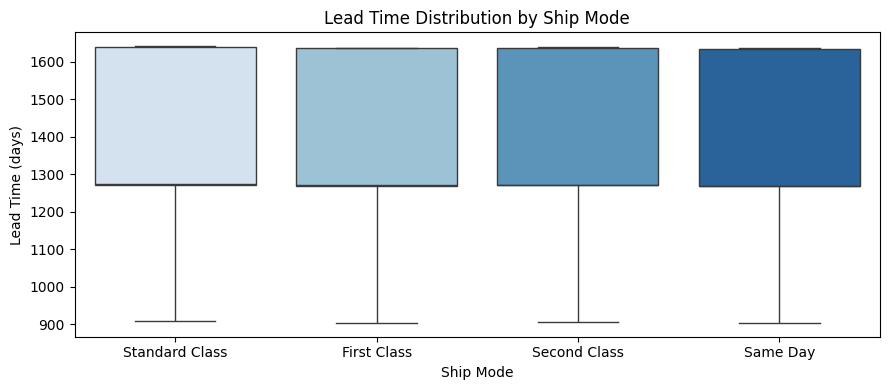

In [11]:
plt.figure(figsize=(9,4))
sns.boxplot(data=df, x='Ship Mode', y='Lead Time', palette='Blues')
plt.title('Lead Time Distribution by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Lead Time (days)')
plt.tight_layout()
plt.show()

C:\Users\khush\AppData\Local\Temp\ipykernel_18940\3110376964.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=factory_lt.values, y=factory_lt.index, palette='Oranges_d')


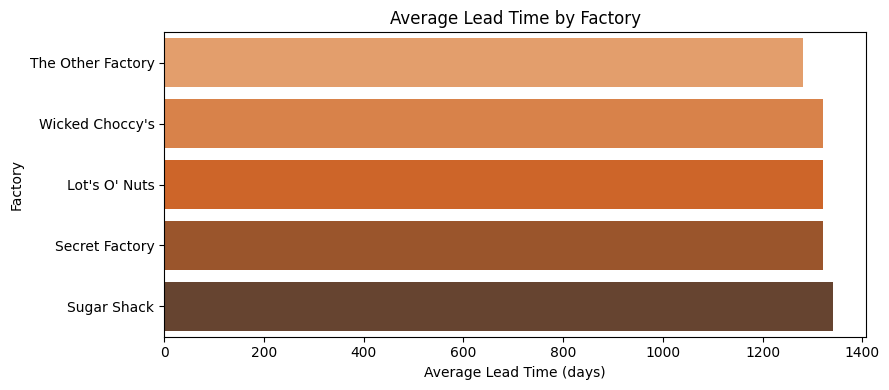

In [12]:
plt.figure(figsize=(9,4))
factory_lt = df.groupby('Factory')['Lead Time'].mean().sort_values()
sns.barplot(x=factory_lt.values, y=factory_lt.index, palette='Oranges_d')
plt.title('Average Lead Time by Factory')
plt.xlabel('Average Lead Time (days)')
plt.ylabel('Factory')
plt.tight_layout()
plt.show()

C:\Users\khush\AppData\Local\Temp\ipykernel_18940\3893394108.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_lt.index, y=region_lt.values, palette='Greens_d')


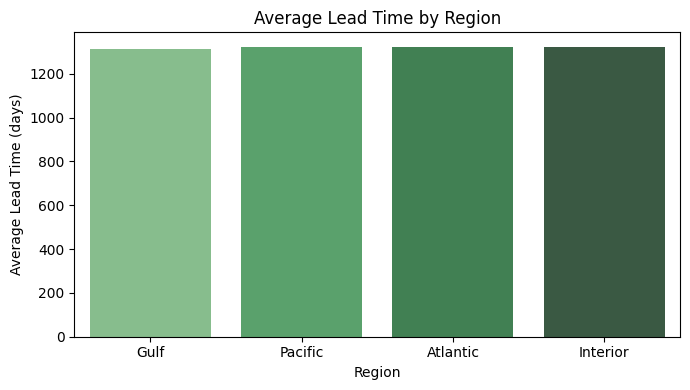

In [13]:
plt.figure(figsize=(7,4))
region_lt = df.groupby('Region')['Lead Time'].mean().sort_values()
sns.barplot(x=region_lt.index, y=region_lt.values, palette='Greens_d')
plt.title('Average Lead Time by Region')
plt.xlabel('Region')
plt.ylabel('Average Lead Time (days)')
plt.tight_layout()
plt.show()

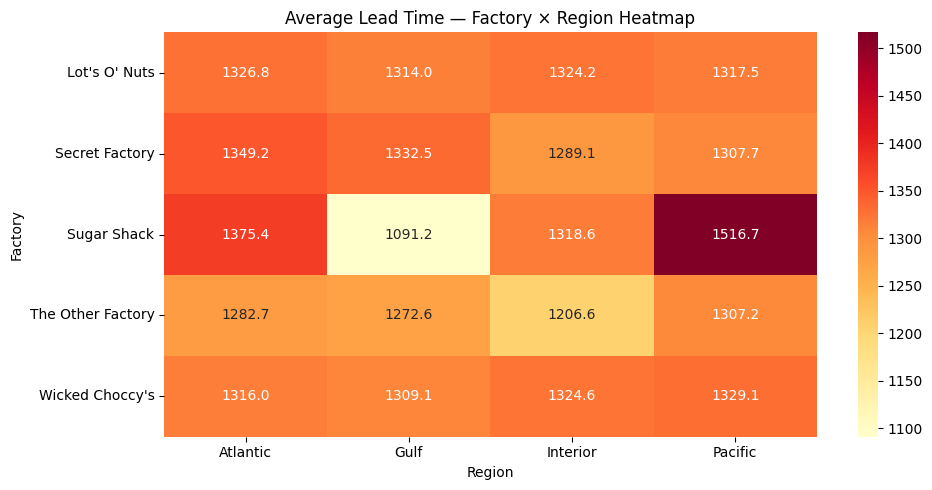

In [14]:
pivot_lt = df.groupby(['Factory','Region'])['Lead Time'].mean().unstack(fill_value=0)
plt.figure(figsize=(10,5))
sns.heatmap(pivot_lt, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('Average Lead Time — Factory × Region Heatmap')
plt.xlabel('Region')
plt.ylabel('Factory')
plt.tight_layout()
plt.show()

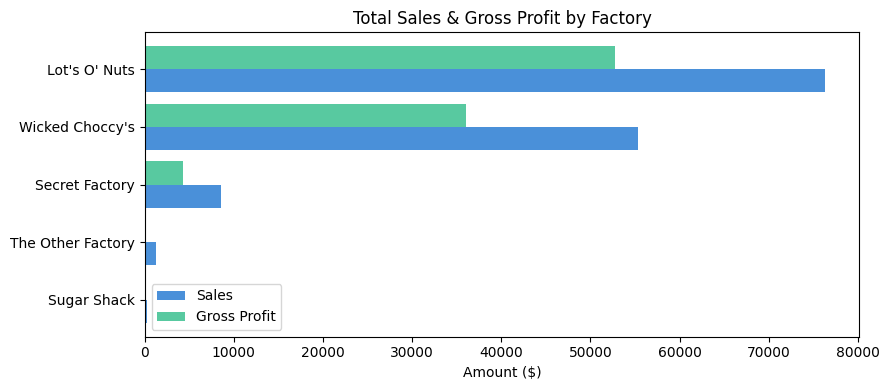

In [15]:
factory_perf = df.groupby('Factory')[['Sales','Gross Profit']].sum().sort_values('Sales')
fig, ax = plt.subplots(figsize=(9,4))
x = range(len(factory_perf))
bars1 = ax.barh([i-0.2 for i in x], factory_perf['Sales'],       height=0.4, label='Sales',        color='#4A90D9')
bars2 = ax.barh([i+0.2 for i in x], factory_perf['Gross Profit'], height=0.4, label='Gross Profit', color='#58C9A0')
ax.set_yticks(list(x))
ax.set_yticklabels(factory_perf.index)
ax.set_xlabel('Amount ($)')
ax.set_title('Total Sales & Gross Profit by Factory')
ax.legend()
plt.tight_layout()
plt.show()

C:\Users\khush\AppData\Local\Temp\ipykernel_18940\391725024.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=div_margin.index, y=div_margin.values, palette='Purples_d')


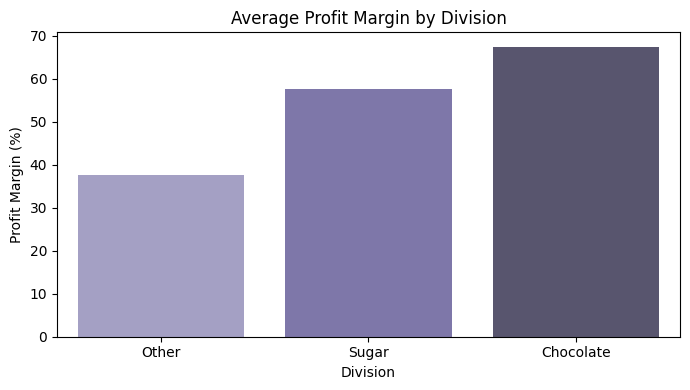

In [16]:
df['Profit Margin (%)'] = (df['Gross Profit'] / df['Sales'] * 100).round(2)
plt.figure(figsize=(7,4))
div_margin = df.groupby('Division')['Profit Margin (%)'].mean().sort_values()
sns.barplot(x=div_margin.index, y=div_margin.values, palette='Purples_d')
plt.title('Average Profit Margin by Division')
plt.xlabel('Division')
plt.ylabel('Profit Margin (%)')
plt.tight_layout()
plt.show()

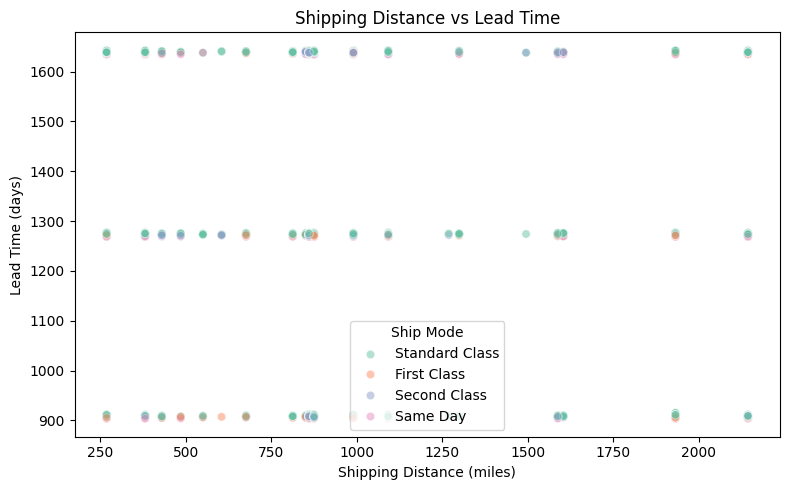

In [17]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Shipping Distance (miles)', y='Lead Time',
                hue='Ship Mode', alpha=0.5, palette='Set2')
plt.title('Shipping Distance vs Lead Time')
plt.xlabel('Shipping Distance (miles)')
plt.ylabel('Lead Time (days)')
plt.legend(title='Ship Mode')
plt.tight_layout()
plt.show()

C:\Users\khush\AppData\Local\Temp\ipykernel_18940\4128330634.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=slow_routes['Avg Lead Time'].values, y=labels, palette='Reds_d')


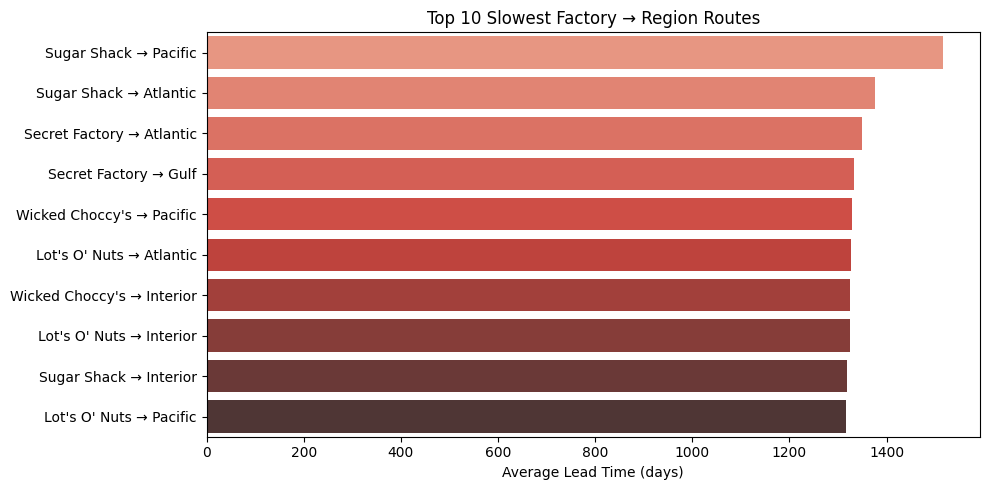

In [18]:
slow_routes = df.groupby(['Factory','Region'])['Lead Time'].mean().reset_index()
slow_routes.columns = ['Factory','Region','Avg Lead Time']
slow_routes = slow_routes.sort_values('Avg Lead Time', ascending=False).head(10)

plt.figure(figsize=(10,5))
labels = [f"{r['Factory']} → {r['Region']}" for _,r in slow_routes.iterrows()]
sns.barplot(x=slow_routes['Avg Lead Time'].values, y=labels, palette='Reds_d')
plt.title('Top 10 Slowest Factory → Region Routes')
plt.xlabel('Average Lead Time (days)')
plt.tight_layout()
plt.show()

In [19]:
print('='*50)
print('     NASSAU CANDY — EDA KPI SUMMARY')
print('='*50)
print(f'  Total Orders          : {len(df):,}')
print(f'  Avg Lead Time         : {df["Lead Time"].mean():.1f} days')
print(f'  Slowest Factory       : {df.groupby("Factory")["Lead Time"].mean().idxmax()}')
print(f'  Fastest Factory       : {df.groupby("Factory")["Lead Time"].mean().idxmin()}')
print(f'  Slowest Region        : {df.groupby("Region")["Lead Time"].mean().idxmax()}')
print(f'  Total Sales           : ${df["Sales"].sum():,.2f}')
print(f'  Total Gross Profit    : ${df["Gross Profit"].sum():,.2f}')
print(f'  Avg Profit Margin     : {df["Profit Margin (%)"].mean():.1f}%')
print(f'  Avg Shipping Distance : {df["Shipping Distance (miles)"].mean():.1f} miles')
print('='*50)

     NASSAU CANDY — EDA KPI SUMMARY
  Total Orders          : 10,194
  Avg Lead Time         : 1320.8 days
  Slowest Factory       : Sugar Shack
  Fastest Factory       : The Other Factory
  Slowest Region        : Interior
  Total Sales           : $141,783.63
  Total Gross Profit    : $93,442.80
  Avg Profit Margin     : 66.5%
  Avg Shipping Distance : 1088.2 miles


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print('✅ ML Libraries loaded!')

ModuleNotFoundError: No module named 'sklearn'

In [21]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 643.7 kB/s eta 0:00:12
   -- ------------------------------------- 0.5/8.0 MB 643.7 kB/s eta 0:00:12
   --- ------------------------------------ 0.8/8.0 MB 765.3 kB/s eta 0:00:10
   ----- ---------------------------------- 1.0/8.0 MB 855.0 kB/s eta 0:00:09
   ------ --------------------------------- 1.3/8.0 MB 873.0 kB/s eta 0:00:08
   ------- -------------------------------- 1.6/8.0 MB 933.7 kB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.0 MB 933.7 kB/s eta 0:00:07
   ------- -------------------------------- 1.6/8.0 MB 933.7 kB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.0 MB 829.2 kB/s eta 0:00:08
   --------- ---------


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print('✅ ML Libraries loaded!')

✅ ML Libraries loaded!


In [23]:
ml_df = df[['Factory', 'Region', 'Ship Mode', 'Division',
            'Shipping Distance (miles)', 'Sales', 'Cost',
            'Gross Profit', 'Units', 'Lead Time']].copy()

le = LabelEncoder()
for col in ['Factory', 'Region', 'Ship Mode', 'Division']:
    ml_df[col] = le.fit_transform(ml_df[col])

X = ml_df.drop('Lead Time', axis=1)
y = ml_df['Lead Time']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print('✅ Features prepared!')
print(f'  Training samples : {X_train.shape[0]:,}')
print(f'  Testing samples  : {X_test.shape[0]:,}')
print(f'  Features used    : {list(X.columns)}')

✅ Features prepared!
  Training samples : 8,155
  Testing samples  : 2,039
  Features used    : ['Factory', 'Region', 'Ship Mode', 'Division', 'Shipping Distance (miles)', 'Sales', 'Cost', 'Gross Profit', 'Units']


In [24]:
models = {
    'Linear Regression'         : LinearRegression(),
    'Random Forest'             : RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting'         : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = round(sqrt(mean_squared_error(y_test, y_pred)), 4)
    mae  = round(mean_absolute_error(y_test, y_pred), 4)
    r2   = round(r2_score(y_test, y_pred), 4)
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'model': model}
    print(f'{name}:')
    print(f'  RMSE : {rmse}')
    print(f'  MAE  : {mae}')
    print(f'  R²   : {r2}')
    print()

Linear Regression:
  RMSE : 266.0542
  MAE  : 214.9016
  R²   : -0.0009

Random Forest:
  RMSE : 277.0164
  MAE  : 224.9128
  R²   : -0.0851

Gradient Boosting:
  RMSE : 267.7923
  MAE  : 216.0327
  R²   : -0.014



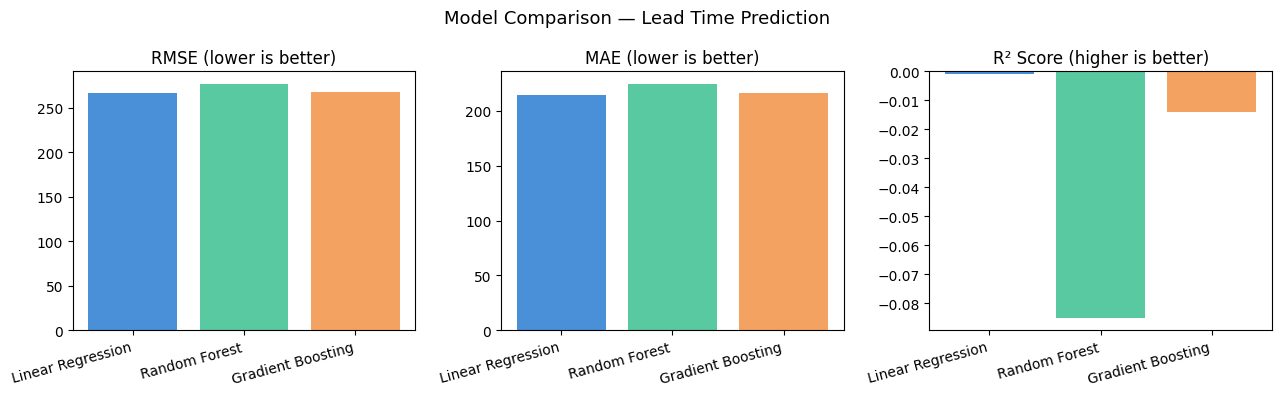

In [25]:
model_names = list(results.keys())
rmse_vals = [results[m]['RMSE'] for m in model_names]
mae_vals  = [results[m]['MAE']  for m in model_names]
r2_vals   = [results[m]['R2']   for m in model_names]

fig, axes = plt.subplots(1, 3, figsize=(13,4))

axes[0].bar(model_names, rmse_vals, color=['#4A90D9','#58C9A0','#F4A261'])
axes[0].set_title('RMSE (lower is better)')
axes[0].set_xticklabels(model_names, rotation=15, ha='right')

axes[1].bar(model_names, mae_vals, color=['#4A90D9','#58C9A0','#F4A261'])
axes[1].set_title('MAE (lower is better)')
axes[1].set_xticklabels(model_names, rotation=15, ha='right')

axes[2].bar(model_names, r2_vals, color=['#4A90D9','#58C9A0','#F4A261'])
axes[2].set_title('R² Score (higher is better)')
axes[2].set_xticklabels(model_names, rotation=15, ha='right')

plt.suptitle('Model Comparison — Lead Time Prediction', fontsize=13)
plt.tight_layout()
plt.show()

In [26]:
best_name = min(results, key=lambda x: results[x]['RMSE'])
best_model = results[best_name]['model']

print('='*45)
print(f'  Best Model : {best_name}')
print(f'  RMSE       : {results[best_name]["RMSE"]}')
print(f'  MAE        : {results[best_name]["MAE"]}')
print(f'  R²         : {results[best_name]["R2"]}')
print('='*45)

  Best Model : Linear Regression
  RMSE       : 266.0542
  MAE        : 214.9016
  R²         : -0.0009


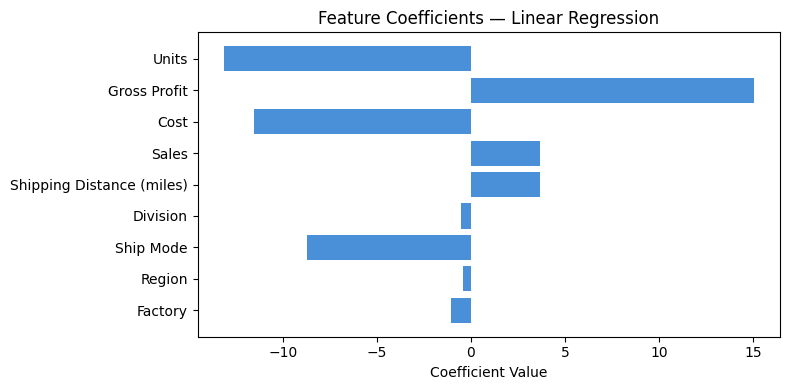

In [27]:
if best_name in ['Random Forest', 'Gradient Boosting']:
    importance = best_model.feature_importances_
    feat_names = list(X.columns)

    plt.figure(figsize=(8,4))
    sorted_idx = importance.argsort()
    plt.barh([feat_names[i] for i in sorted_idx],
             [importance[i] for i in sorted_idx],
             color='#4A90D9')
    plt.title(f'Feature Importance — {best_name}')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()
else:
    coefs = best_model.coef_
    feat_names = list(X.columns)
    plt.figure(figsize=(8,4))
    plt.barh(feat_names, coefs, color='#4A90D9')
    plt.title('Feature Coefficients — Linear Regression')
    plt.xlabel('Coefficient Value')
    plt.tight_layout()
    plt.show()

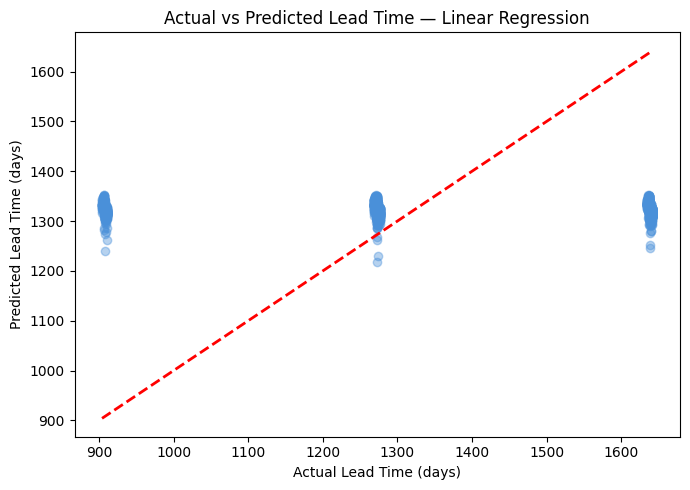


✅ Best model saved: Linear Regression
Ready for Phase 4 — Scenario Simulation!


In [28]:
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(7,5))
plt.scatter(y_test, y_pred_best, alpha=0.4, color='#4A90D9')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title(f'Actual vs Predicted Lead Time — {best_name}')
plt.xlabel('Actual Lead Time (days)')
plt.ylabel('Predicted Lead Time (days)')
plt.tight_layout()
plt.show()

print(f'\n✅ Best model saved: {best_name}')
print(f'Ready for Phase 4 — Scenario Simulation!')

In [29]:
all_factories = list(factory_coords.keys())

factory_encoder = LabelEncoder()
factory_encoder.fit(ml_df['Factory'] if 'Factory' in ml_df.columns 
                    else [le.transform([f])[0] for f in all_factories])

region_encoder  = LabelEncoder().fit(df['Region'])
shipmode_encoder = LabelEncoder().fit(df['Ship Mode'])
division_encoder = LabelEncoder().fit(df['Division'])

print('✅ Encoders ready!')
print(f'Factories: {all_factories}')

✅ Encoders ready!
Factories: ["Lot's O' Nuts", "Wicked Choccy's", 'Sugar Shack', 'Secret Factory', 'The Other Factory']


In [30]:
def simulate_factory(product_name, target_factory, region, ship_mode):
    row = df[df['Product Name'] == product_name].iloc[0]
    division = row['Division']

    f_lat, f_lon = factory_coords[target_factory]
    r_lat, r_lon = region_coords[region]
    distance = haversine(f_lat, f_lon, r_lat, r_lon)

    features = {
        'Factory'                   : le.fit_transform(pd.Series([target_factory]))[0],
        'Region'                    : le.fit_transform(pd.Series([region]))[0],
        'Ship Mode'                 : le.fit_transform(pd.Series([ship_mode]))[0],
        'Division'                  : le.fit_transform(pd.Series([division]))[0],
        'Shipping Distance (miles)' : distance,
        'Sales'                     : row['Sales'],
        'Cost'                      : row['Cost'],
        'Gross Profit'              : row['Gross Profit'],
        'Units'                     : row['Units']
    }

    feat_array = np.array([[features[col] for col in X.columns]])
    feat_scaled = scaler.transform(feat_array)
    predicted_lt = best_model.predict(feat_scaled)[0]
    return round(predicted_lt, 2), round(distance, 2)

print('✅ Simulation function ready!')

✅ Simulation function ready!


In [31]:
simulation_results = []

products = df['Product Name'].unique()
regions  = df['Region'].unique()
ship_modes = df['Ship Mode'].unique()

for product in products:
    current_factory = product_factory.get(product, None)
    if not current_factory:
        continue

    for region in regions:
        for ship_mode in ship_modes:
            current_lt, current_dist = simulate_factory(
                product, current_factory, region, ship_mode)

            for alt_factory in all_factories:
                if alt_factory == current_factory:
                    continue
                alt_lt, alt_dist = simulate_factory(
                    product, alt_factory, region, ship_mode)
                lt_reduction = round(current_lt - alt_lt, 2)
                lt_reduction_pct = round((lt_reduction / current_lt) * 100, 2) if current_lt > 0 else 0

                simulation_results.append({
                    'Product'              : product,
                    'Current Factory'      : current_factory,
                    'Alt Factory'          : alt_factory,
                    'Region'               : region,
                    'Ship Mode'            : ship_mode,
                    'Current Lead Time'    : current_lt,
                    'Alt Lead Time'        : alt_lt,
                    'LT Reduction (days)'  : lt_reduction,
                    'LT Reduction (%)'     : lt_reduction_pct,
                    'Current Distance'     : current_dist,
                    'Alt Distance'         : alt_dist,
                })

sim_df = pd.DataFrame(simulation_results)
print(f'✅ Simulation complete! {len(sim_df):,} scenarios generated')
display(sim_df.head(10))

✅ Simulation complete! 960 scenarios generated


,Product,Current Factory,Alt Factory,Region,Ship Mode,Current Lead Time,Alt Lead Time,LT Reduction (days),LT Reduction (%),Current Distance,Alt Distance
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Interior,Standard Class,1343.61,1342.41,1.20,0.09,1092.4,875.45
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,Interior,Standard Class,1343.61,1340.92,2.69,0.20,1092.4,605.20
2,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,Interior,Standard Class,1343.61,1339.95,3.66,0.27,1092.4,430.51
3,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,Interior,Standard Class,1343.61,1340.62,2.99,0.22,1092.4,550.73
4,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Interior,First Class,1343.61,1342.41,1.20,0.09,1092.4,875.45
5,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,Interior,First Class,1343.61,1340.92,2.69,0.20,1092.4,605.20
6,Wonka Bar - Milk Chocolate,Wicked Choccy's,Secret Factory,Interior,First Class,1343.61,1339.95,3.66,0.27,1092.4,430.51
7,Wonka Bar - Milk Chocolate,Wicked Choccy's,The Other Factory,Interior,First Class,1343.61,1340.62,2.99,0.22,1092.4,550.73
8,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Interior,Second Class,1343.61,1342.41,1.20,0.09,1092.4,875.45
9,Wonka Bar - Milk Chocolate,Wicked Choccy's,Sugar Shack,Interior,Second Class,1343.61,1340.92,2.69,0.20,1092.4,605.20


In [32]:
best_recs = sim_df[sim_df['LT Reduction (days)'] > 0].copy()
best_recs = best_recs.sort_values('LT Reduction (%)', ascending=False)

top_recs = best_recs.groupby(['Product','Region','Ship Mode']).first().reset_index()
top_recs = top_recs.sort_values('LT Reduction (%)', ascending=False).head(20)

print(f'✅ Top 20 Recommendations:')
display(top_recs[['Product','Current Factory','Alt Factory',
                  'Region','Ship Mode','Current Lead Time',
                  'Alt Lead Time','LT Reduction (%)']].reset_index(drop=True))

✅ Top 20 Recommendations:


,Product,Current Factory,Alt Factory,Region,Ship Mode,Current Lead Time,Alt Lead Time,LT Reduction (%)
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,First Class,1349.41,1339.68,0.72
1,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,Same Day,1349.41,1339.68,0.72
2,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,Second Class,1349.41,1339.68,0.72
3,Wonka Bar - Milk Chocolate,Wicked Choccy's,Lot's O' Nuts,Pacific,Standard Class,1349.41,1339.68,0.72
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Pacific,First Class,1350.54,1340.81,0.72
5,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Pacific,Same Day,1350.54,1340.81,0.72
6,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Pacific,Second Class,1350.54,1340.81,0.72
7,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Lot's O' Nuts,Pacific,Standard Class,1350.54,1340.81,0.72
8,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,Atlantic,First Class,1348.84,1339.66,0.68
9,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Wicked Choccy's,Atlantic,Same Day,1348.84,1339.66,0.68


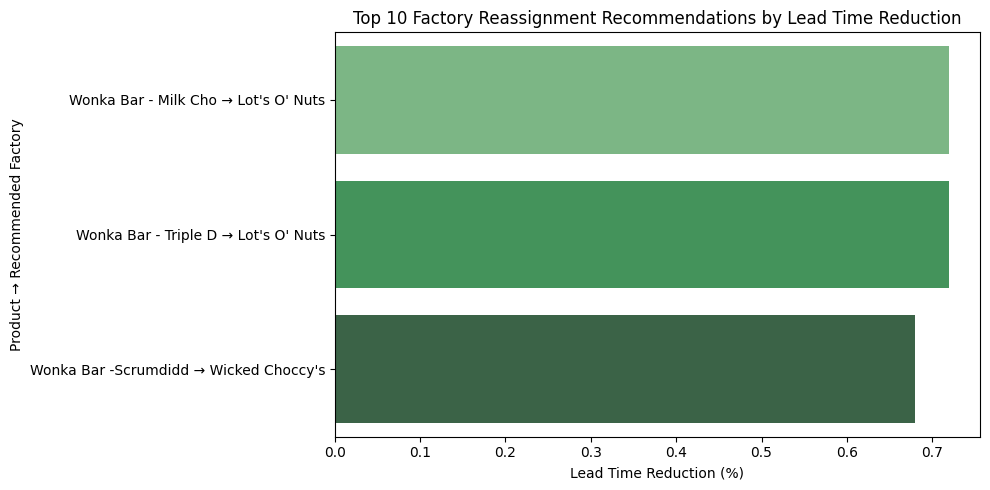

In [33]:
top10 = top_recs.head(10).copy()
top10['Label'] = top10['Product'].str[:20] + ' → ' + top10['Alt Factory']

plt.figure(figsize=(10,5))
sns.barplot(x=top10['LT Reduction (%)'], y=top10['Label'], palette='Greens_d')
plt.title('Top 10 Factory Reassignment Recommendations by Lead Time Reduction')
plt.xlabel('Lead Time Reduction (%)')
plt.ylabel('Product → Recommended Factory')
plt.tight_layout()
plt.show()

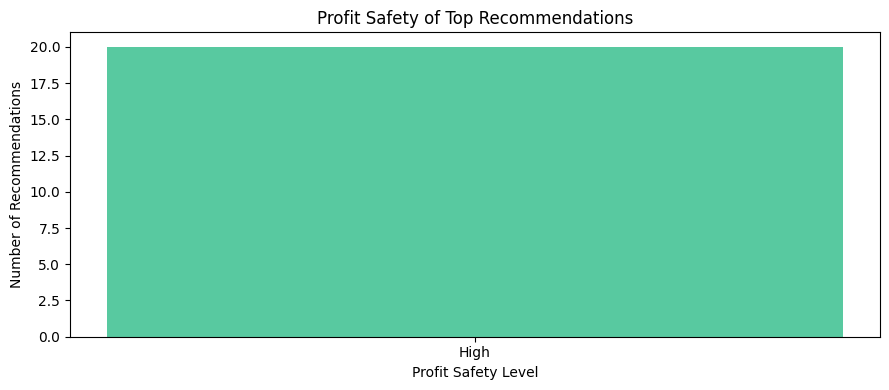

In [34]:
product_profit = df.groupby('Product Name')['Gross Profit'].mean().reset_index()
product_profit.columns = ['Product','Avg Gross Profit']

top_recs = top_recs.merge(product_profit, on='Product', how='left')
top_recs['Profit Safety'] = top_recs['Avg Gross Profit'].apply(
    lambda x: 'High' if x > 8 else ('Medium' if x > 5 else 'Low'))

plt.figure(figsize=(9,4))
profit_counts = top_recs['Profit Safety'].value_counts()
colors = {'High':'#58C9A0', 'Medium':'#F4A261', 'Low':'#E87D7D'}
plt.bar(profit_counts.index,
        profit_counts.values,
        color=[colors[k] for k in profit_counts.index])
plt.title('Profit Safety of Top Recommendations')
plt.xlabel('Profit Safety Level')
plt.ylabel('Number of Recommendations')
plt.tight_layout()
plt.show()

In [35]:
sim_df['Risk Level'] = sim_df['Alt Distance'].apply(
    lambda x: 'High Risk' if x > 1500 else ('Medium Risk' if x > 800 else 'Low Risk'))

print('='*50)
print('   NASSAU CANDY — OPTIMIZATION SUMMARY')
print('='*50)
print(f'  Total scenarios simulated : {len(sim_df):,}')
print(f'  Beneficial reassignments  : {len(best_recs):,}')
print(f'  Max LT reduction          : {sim_df["LT Reduction (days)"].max():.1f} days')
print(f'  Avg LT reduction          : {best_recs["LT Reduction (days)"].mean():.1f} days')
print(f'\n  Risk Distribution:')
print(sim_df['Risk Level'].value_counts().to_string())
print('='*50)

sim_df.to_csv('simulation_results.csv', index=False)
top_recs.to_csv('top_recommendations.csv', index=False)
print('\n✅ Results saved to CSV files!')
print('Ready for Phase 5 — Streamlit Dashboard!')

   NASSAU CANDY — OPTIMIZATION SUMMARY
  Total scenarios simulated : 960
  Beneficial reassignments  : 500
  Max LT reduction          : 9.7 days
  Avg LT reduction          : 3.0 days

  Risk Distribution:
Risk Level
Medium Risk    416
Low Risk       344
High Risk      200

✅ Results saved to CSV files!
Ready for Phase 5 — Streamlit Dashboard!
